In [23]:
import pandas as pd

file_name = "sleep_health_dataset.csv"
df = pd.read_csv(file_name)

#Load the Data from CSV to Python
print("Data loaded successfully!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Data loaded successfully!
Total Rows: 100000
Total Columns: 32


In [24]:
#cleaning data by removing duplicates and null values
print("\n--- Data Health Check ---")

missing_data = df.isnull().sum()
print("\nMissing data from columns:\n",missing_data)

duplicate_count = df.duplicated().sum()
print(f"\nTotal number of duplicated rows:", duplicate_count)


--- Data Health Check ---

Missing data from columns:
 person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type            

In [25]:
#numerical exploration: describes the mean, std, min, max of the numerical columns
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [26]:
#categorical exploration
print("--- Occupations of People ---")
print(df['occupation'].value_counts())

print("\n--- Sleep Disorder Risks ---")
print(df['sleep_disorder_risk'].value_counts())

--- Occupations of People ---
occupation
Student              14851
Software Engineer    12068
Nurse                10073
Manager               8101
Teacher               8047
Doctor                7868
Retired               7036
Sales                 7017
Freelancer            7016
Driver                6996
Homemaker             5923
Lawyer                5004
Name: count, dtype: int64

--- Sleep Disorder Risks ---
sleep_disorder_risk
Healthy     54156
Mild        33479
Moderate     8299
Severe       4066
Name: count, dtype: int64


/var/folders/0l/x1pf8gvx5bg8r1z82xwj121c0000gn/T/ipykernel_13210/2262952246.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


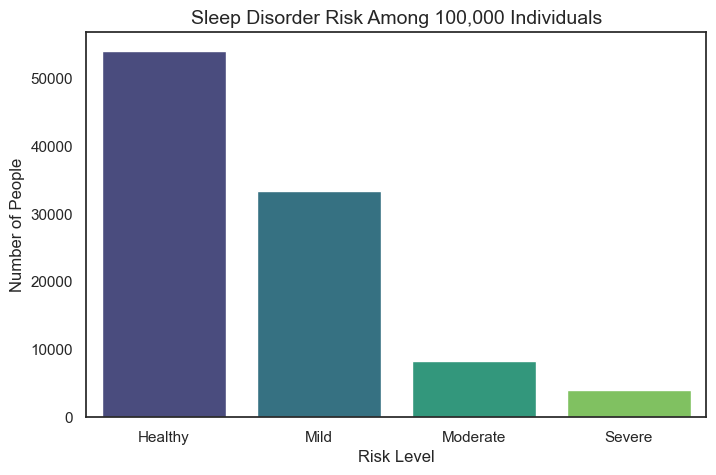

In [27]:
#Sleep Disorder Risk for 100,000 individuals

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='white')

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='sleep_disorder_risk',
    order=['Healthy','Mild','Moderate','Severe'],
    palette='viridis'
)

plt.title("Sleep Disorder Risk Among 100,000 Individuals", fontsize = 14)
plt.xlabel("Risk Level", fontsize=12)
plt.ylabel("Number of People", fontsize=12)

plt.show()

/var/folders/0l/x1pf8gvx5bg8r1z82xwj121c0000gn/T/ipykernel_13210/1291437952.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


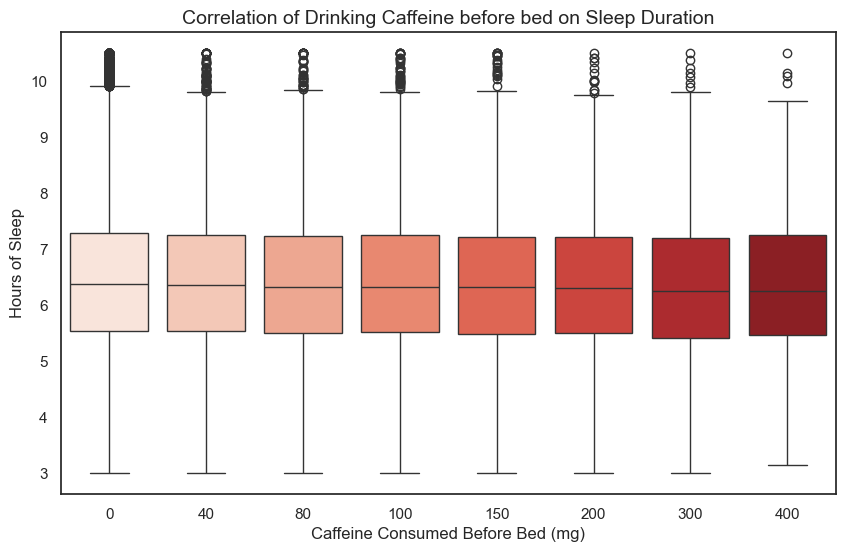

In [28]:
#Correlation of Caffeine on Sleep Duration

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x = 'caffeine_mg_before_bed',
    y = 'sleep_duration_hrs',
    palette='Reds'
)

plt.title("Correlation of Drinking Caffeine before bed on Sleep Duration", fontsize=14)
plt.xlabel("Caffeine Consumed Before Bed (mg)", fontsize = 12)
plt.ylabel("Hours of Sleep",fontsize=12)
plt.show()

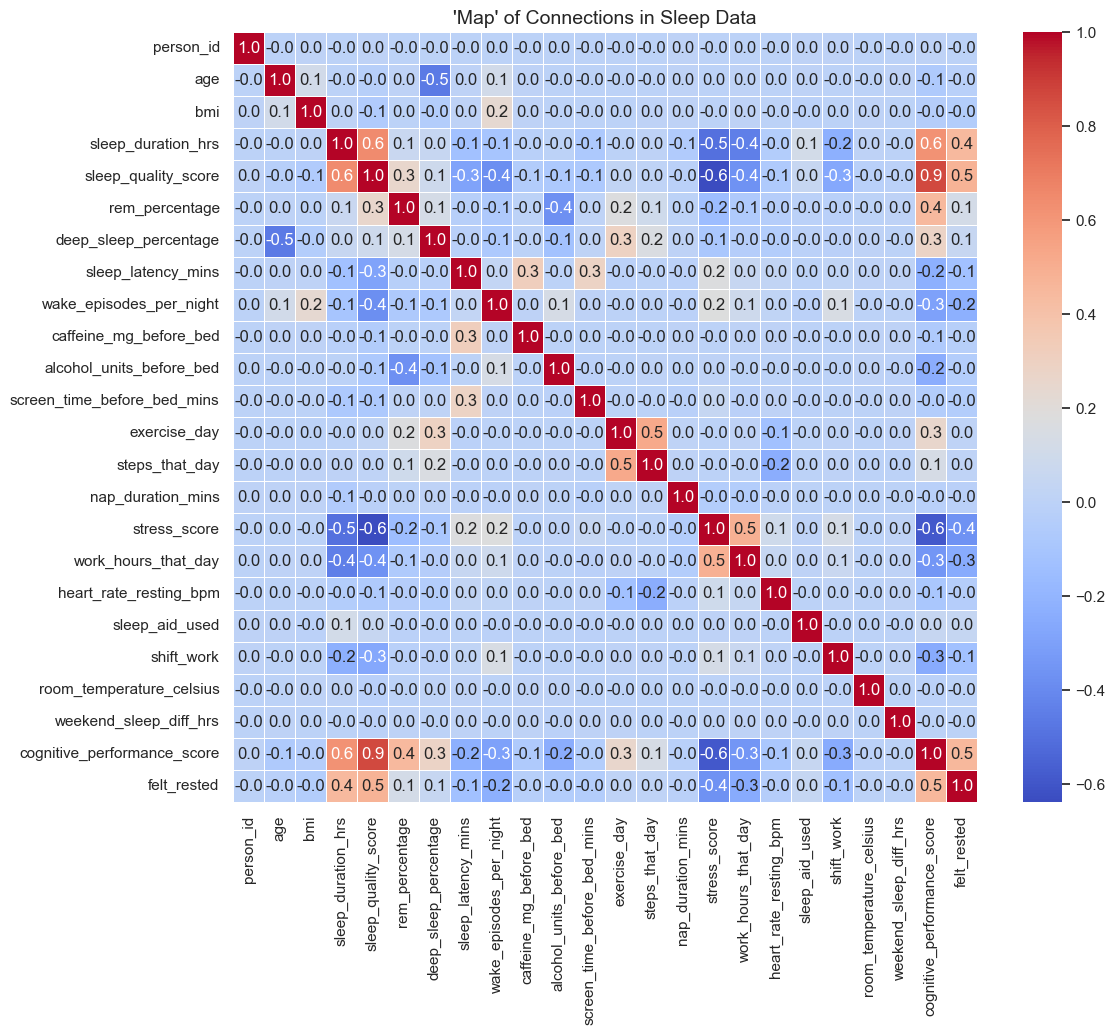

In [29]:
numeric_df = df.select_dtypes(include=['float64','int64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt=".1f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("'Map' of Connections in Sleep Data", fontsize = 14)
plt.show()

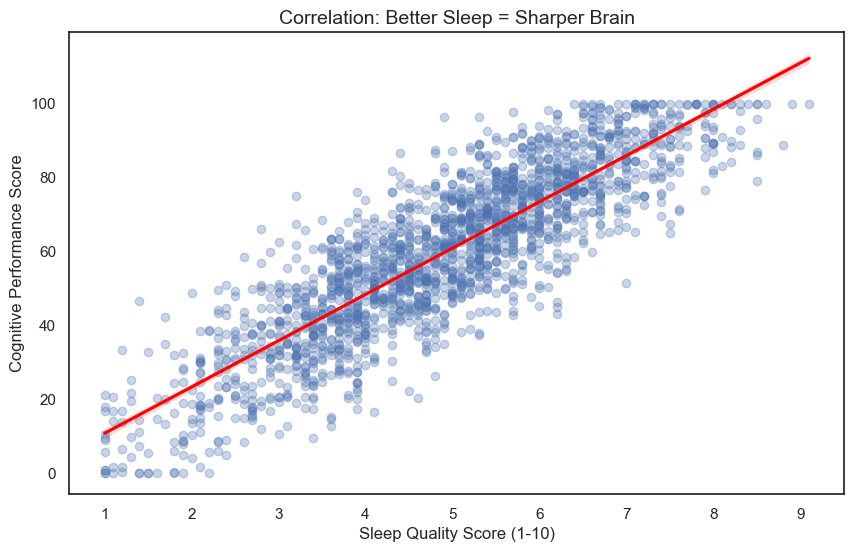

In [30]:
#sleep vs brain scatter plot
plt.figure(figsize=(10,6))
sns.regplot(
    data=df.sample(2000),
    x='sleep_quality_score',
    y='cognitive_performance_score',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title("Correlation: Better Sleep = Sharper Brain", fontsize=14)
plt.xlabel("Sleep Quality Score (1-10)", fontsize=12)
plt.ylabel("Cognitive Performance Score", fontsize=12)
plt.show()

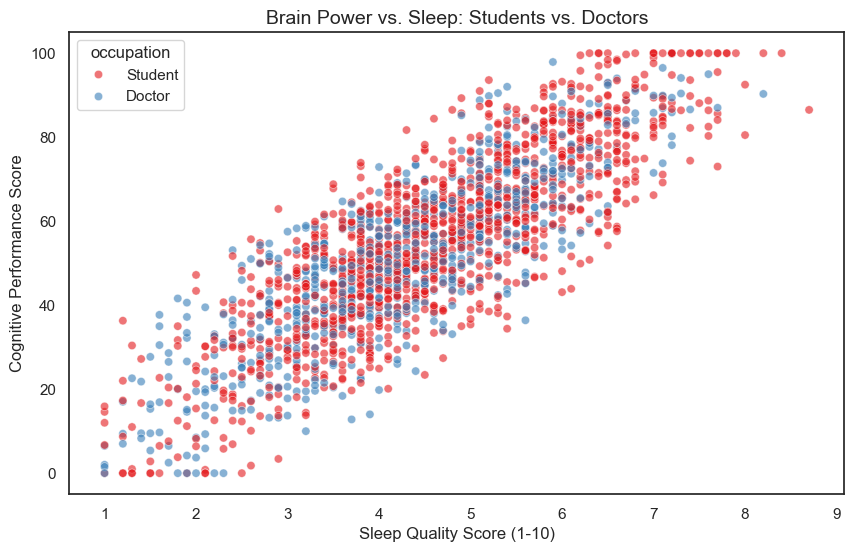

In [31]:
#We will filter Students vs Doctors

filtered_df = df[(df['occupation']=='Student') | (df['occupation']=='Doctor')]
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=filtered_df.sample(2000),
    x='sleep_quality_score',
    y='cognitive_performance_score',
    hue='occupation',
    palette='Set1',
    alpha=0.6
)

plt.title("Brain Power vs. Sleep: Students vs. Doctors", fontsize=14)
plt.xlabel("Sleep Quality Score (1-10)", fontsize=12)
plt.ylabel("Cognitive Performance Score", fontsize=12)
plt.show()


/var/folders/0l/x1pf8gvx5bg8r1z82xwj121c0000gn/T/ipykernel_13210/654575387.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


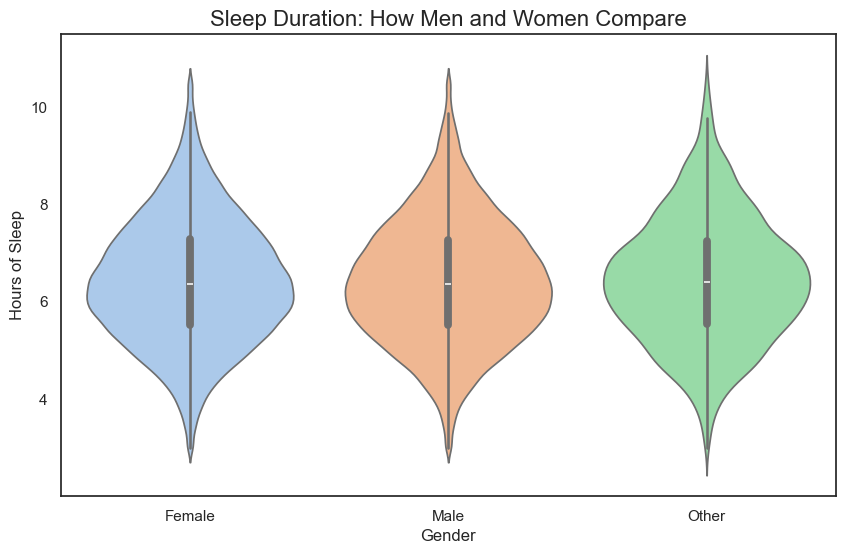

In [32]:
#Men vs. Women in Sleep

plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x='gender',
    y='sleep_duration_hrs',
    palette='pastel'
)

plt.title("Sleep Duration: How Men and Women Compare", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Hours of Sleep", fontsize=12)

plt.show()



/var/folders/0l/x1pf8gvx5bg8r1z82xwj121c0000gn/T/ipykernel_13210/104833280.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


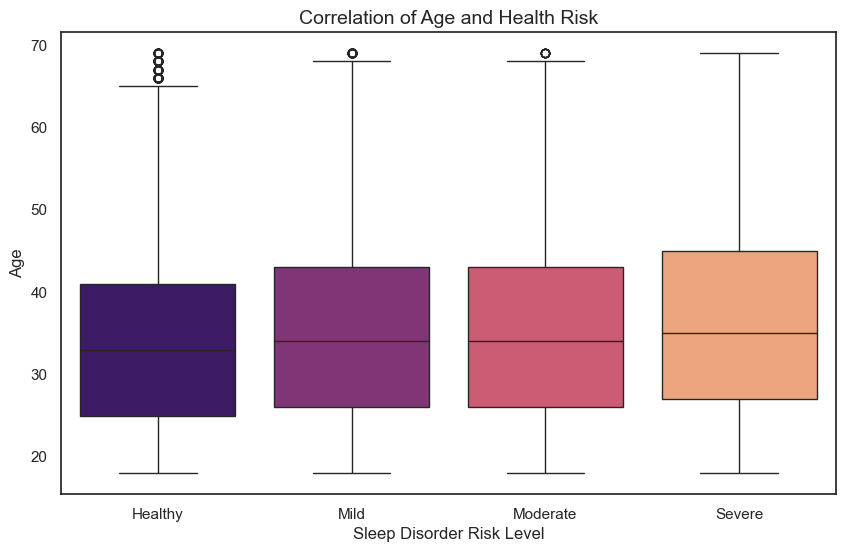

In [35]:
#We will use box plot to show whether there is a correlation of age and level of risk

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='sleep_disorder_risk',
    y='age',
    order=['Healthy', 'Mild', 'Moderate', 'Severe'],
    palette='magma'
)

plt.title('Correlation of Age and Health Risk', fontsize=14)
plt.xlabel('Sleep Disorder Risk Level', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.show()